## Install Packages for the Environment via Anaconda

Follow these steps to install new packages:

1. **Activate the Environment**  
   After creating the environment, activate it using:  
   **`conda activate ErSE222`**

2. **Install CV2**  
   Once the environment is activated, install torchvision with:  
   **`pip install opencv-python`**  
   *Usage*: dealing with images..

# Salt segmentation

 For this example we will use the openly available dataset from the [TGS Kaggle Competition](https://www.kaggle.com/c/tgs-salt-identification-challenge).
 
Or download from Google Drive [Drive](https://drive.google.com/file/d/17ANUmZH1pP1TYVQfRDBzdsmqH9OxMLVx/view?usp=sharing)

More specifically, this notebook is organized as follows:

- Load dataset from a collection of .png images as provided in the Kaggle competition. For this we will rely on the `Dataset` module in Torch
- Perform a number of data augumentation stategies such as De-meaning or Polarity flipping
- Train a UNet to segment the images in binary masks (0: no salt, 1: salt)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time


np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


## Reading Data

In [2]:
import os
ids = next(os.walk(r"./data/Salt/images"))[2] # list of names all images in the given path
print("No. of images = ", len(ids))

labels_folder = r"./data/Salt/masks/"
images_folder = r"./data/Salt/images/"

print(labels_folder)
print(images_folder)

No. of images =  4000
./data/Salt/masks/
./data/Salt/images/


In [3]:
import glob
import cv2
import numpy as np
X = []
Y = []
for filename in glob.glob(images_folder + "*.png"):
    img = cv2.imread(filename)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img,(128,128))
    
    mask = cv2.imread(labels_folder + os.path.split(filename)[1])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = cv2.resize(mask,(128,128))
    
    X.append(img)
    Y.append(mask)

# normalize the data and the labels
X = np.array(X)
X = X/255

Y = np.array(Y)
Y = Y/255



print(X.shape)
print(Y.shape)


(4000, 128, 128, 3)
(4000, 128, 128)


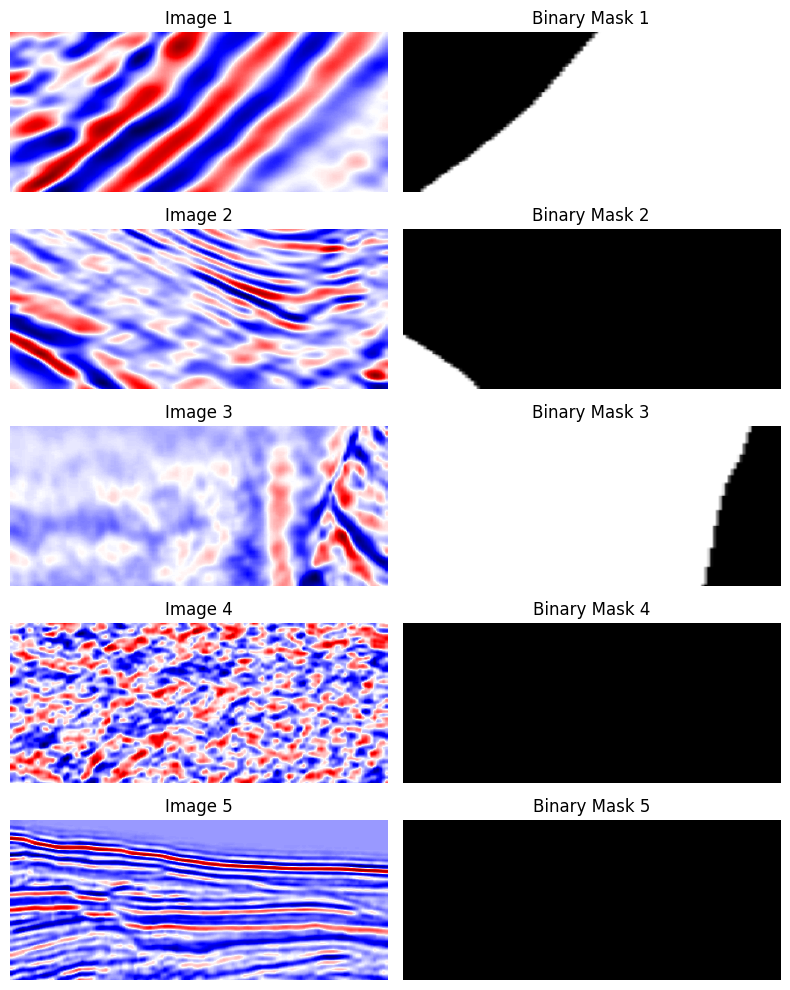

In [4]:
from matplotlib import pyplot as plt

# Assuming X is of shape (num_samples, height, width, channels) where channels = 3 for RGB
# Assuming Y is of shape (num_samples, height, width) for binary masks

num_examples = 5
fig, axes = plt.subplots(num_examples, 2, figsize=(8, 10))

for k in range(num_examples):
    axes[k, 0].imshow(X[k, :, :, 0], aspect='auto', cmap='seismic')  # Display RGB image
    axes[k, 0].set_title(f'Image {k + 1}')
    axes[k, 0].axis('off')

    axes[k, 1].imshow(Y[k, :, :], aspect='auto', cmap='gray')  # Display binary mask
    axes[k, 1].set_title(f'Binary Mask {k + 1}')
    axes[k, 1].axis('off')

plt.tight_layout()
plt.show()

## UNET

In [5]:
import torch
import torch.nn as nn

class UNET(nn.Module):
    def __init__(self, input_channels, FM1, FM2, FM3, bottleneck_dim, output_channels):
        super(UNET, self).__init__()
        
        # Encoder
        self.encoder_conv1 = nn.Conv2d(input_channels, FM1, kernel_size=3, stride=1, padding=1)
        self.encoder_ac1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder_conv2 = nn.Conv2d(FM1, FM2, kernel_size=3, stride=1, padding=1)  # Same feature maps
        self.encoder_ac2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder_conv3 = nn.Conv2d(FM2, FM3, kernel_size=3, stride=1, padding=1)
        self.encoder_ac3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder_bottleneck = nn.Conv2d(FM3, bottleneck_dim, kernel_size=3, stride=1, padding=1)  # Bottleneck with 1 feature map
        self.encoder_bottleneck_ac = nn.ReLU()

        # Decoder
        self.decoder_upsample1 = nn.Upsample(scale_factor=2, mode='bilinear')
        self.decoder_conv1 = nn.Conv2d(bottleneck_dim, FM3, kernel_size=3, padding=1)
        self.decoder_ac1 = nn.ReLU()

        self.decoder_upsample2 = nn.Upsample(scale_factor=2, mode='bilinear')
        self.decoder_conv2 = nn.Conv2d(FM3, FM2, kernel_size=3, padding=1)
        self.decoder_ac2 = nn.ReLU()

        self.decoder_upsample3 = nn.Upsample(scale_factor=2, mode='bilinear')
        self.decoder_conv3 = nn.Conv2d(FM2, FM1, kernel_size=3, padding=1)
        self.decoder_ac3 = nn.ReLU()

        self.decoder_convF = nn.Conv2d(FM1, output_channels, kernel_size=3, padding=1)  # Final output layer
        self.decoder_acF = nn.Sigmoid()

    def forward(self, x):
        # Encoding
        E1 = self.encoder_conv1(x)
        E1 = self.encoder_ac1(E1)
        P1 = self.pool1(E1)

        E2 = self.encoder_conv2(P1)
        E2 = self.encoder_ac2(E2)
        P2 = self.pool2(E2)

        E3 = self.encoder_conv3(P2)
        E3 = self.encoder_ac3(E3)
        P3 = self.pool3(E3)

        # Bottleneck
        B = self.encoder_bottleneck(P3)
        B = self.encoder_bottleneck_ac(B)

        # Decoding
        D1 = self.decoder_upsample1(B)
        D1 = self.decoder_conv1(D1)
        D1 = self.decoder_ac1(D1)
        D1 = D1 + E3  # Skip connection

        D2 = self.decoder_upsample2(D1)
        D2 = self.decoder_conv2(D2)
        D2 = self.decoder_ac2(D2)
        D2 = D2 + E2  # Skip connection

        D3 = self.decoder_upsample3(D2)
        D3 = self.decoder_conv3(D3)
        D3 = self.decoder_ac3(D3)
        D3 = D3 + E1  # Skip connection
        
        out = self.decoder_convF(D3)  # Final output layer
        out = self.decoder_acF(out)
        
        return B, out

## Data preparation

In [6]:
# Reshaping the data
Y = np.reshape(Y,(Y.shape[0], 1, Y.shape[1], Y.shape[2]))
X = np.reshape(X,(X.shape[0], 3, X.shape[1], X.shape[2]))

In [7]:
from torch.utils.data import Dataset, DataLoader

# 1. Define your Dataset class (if you haven't already):

class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)  # Convert to torch tensor
        self.labels = torch.tensor(labels, dtype=torch.float32) #Convert labels to long for classification

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [8]:
from sklearn.model_selection import train_test_split
from torchvision import transforms


batch_size = 128
# data and labels to tensor
datainput = torch.tensor(torch.tensor(X),dtype=torch.float32)
labelout = torch.tensor(torch.tensor(Y),dtype=torch.float32)


# Divide the data into train and test
train_data, test_data, train_labels, test_labels = train_test_split(
    datainput, labelout, test_size=0.1, random_state=42)

# Create your Dataset instance
dataset_train = MyDataset(train_data, train_labels)
dataset_test  = MyDataset(test_data, test_labels)

# Create a DataLoader
# Adjust batch_size as needed; shuffle=True for training

train_loader = torch.utils.data.DataLoader(dataset=dataset_train, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=dataset_test, 
                                          batch_size=batch_size, 
                                          shuffle=False)

/tmp/ipykernel_3967225/477440712.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  datainput = torch.tensor(torch.tensor(X),dtype=torch.float32)
/tmp/ipykernel_3967225/477440712.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labelout = torch.tensor(torch.tensor(Y),dtype=torch.float32)


In [9]:

input_channels = 3
FM1 = 128
FM2 = 2*FM1
FM3 = 2*FM2
bottleneck_dim = 2*FM3
output_channels = 1

model = UNET(input_channels, FM1, FM2, FM3, bottleneck_dim, output_channels).to(device)
print(model)


criterion = nn.BCELoss()


learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  

# Train the model
model.train()
num_epochs = 100

for epoch in range(num_epochs):
    losall = 0
    for i, (images, labels) in enumerate(train_loader):
        # Load images with gradient accumulation capabilities
        images = images.requires_grad_(True).to(device)
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
        
        # Forward pass to get output/logits
        E, outputs = model(images)
        
        # Calculate Loss
        loss = criterion(outputs, labels)
        losall+= loss.item()
        
        # Getting gradients w.r.t. parameters
        loss.backward()
        
        # Updating parameters
        optimizer.step()
        
    
            
    # Print Loss
    print('epoch: {}. Loss: {}'.format(epoch, losall))
    
# Save Model
torch.save(model.state_dict(), 'data/Salt/model_weights_UNET.pth')


UNET(
  (encoder_conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_ac1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder_conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_ac2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder_conv3): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_ac3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder_bottleneck): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_bottleneck_ac): ReLU()
  (decoder_upsample1): Upsample(scale_factor=2.0, mode='bilinear')
  (decoder_conv1): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder_ac1): ReLU()
  (decoder_upsample2): Upsample(scale_factor=2.0, mode='bilinear')
  (decoder_conv2): Conv2d(512, 2

In [10]:
# Load Best Model
model.load_state_dict(torch.load('data/Salt/model_weights_UNET.pth'))

laball = []
dat = []
outputsall= []
Eall = []
# Iterate through test dataset
for images, labels in test_loader:
    # Load images with gradient accumulation capabilities
    images = images.requires_grad_(True).to(device)
    labels = labels.to(device)


    # Forward pass only to get logits/output
    E, outputs = model(images)

    
    laball.append(labels.cpu().numpy())
    dat.append(images.detach().cpu().numpy())
    outputsall.append(outputs.detach().cpu().numpy())

    

outputsall = np.concatenate(outputsall)
laball = np.concatenate(laball)
dat = np.concatenate(dat)

# Print Loss
print('Loss: {}'.format(loss.item()))

Loss: 0.10452590882778168


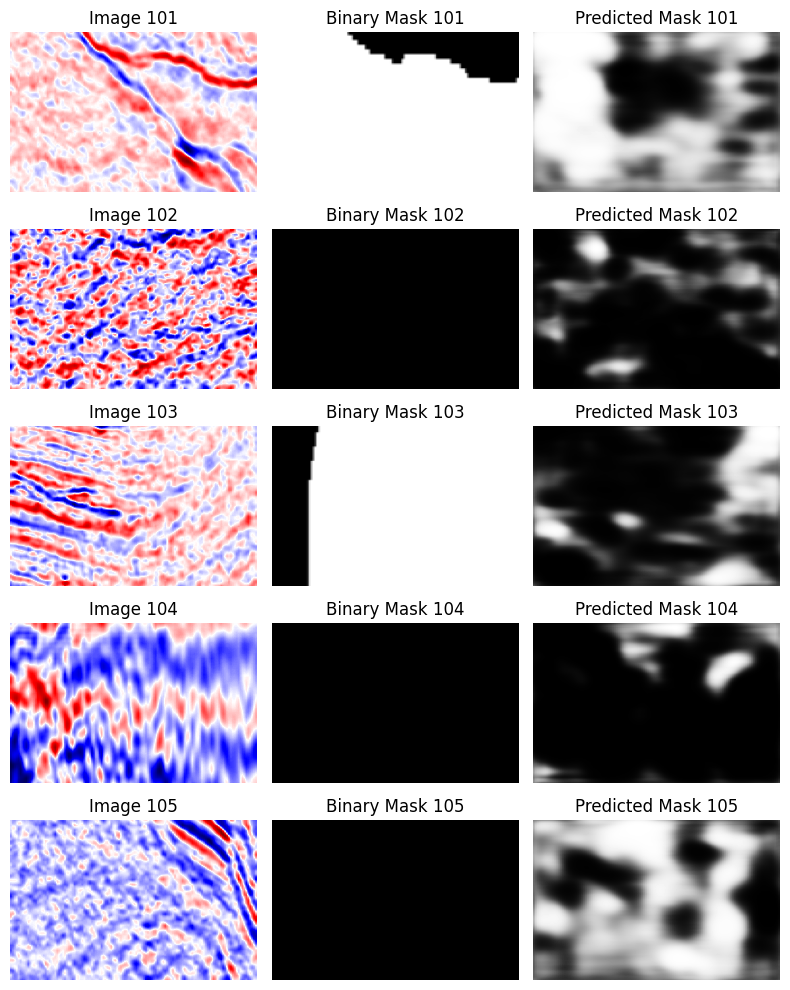

In [11]:
from matplotlib import pyplot as plt

# Assuming X is of shape (num_samples, height, width, channels) where channels = 3 for RGB
# Assuming Y is of shape (num_samples, height, width) for binary masks

num_examples = 5
ref = 100
c= 0
fig, axes = plt.subplots(num_examples, 3, figsize=(8, 10))

for k in range(ref,ref+num_examples):
    datplot = dat[k].reshape((dat.shape[2],dat.shape[3],3))
    #predmask = outputsall[k].reshape((outputsall.shape[2],outputsall.shape[3],1))

    axes[c, 0].imshow(datplot[:,:,0], aspect='auto', cmap='seismic')  # Display RGB image
    axes[c, 0].set_title(f'Image {k + 1}')
    axes[c, 0].axis('off')

    axes[c, 1].imshow(laball[k][0], aspect='auto', cmap='gray')  # Display binary mask
    axes[c, 1].set_title(f'Binary Mask {k + 1}')
    axes[c, 1].axis('off')
    
    axes[c, 2].imshow(outputsall[k][0], aspect='auto', cmap='gray')  # Display binary mask
    axes[c, 2].set_title(f'Predicted Mask {k + 1}')
    axes[c, 2].axis('off')
    
    c+=1

plt.tight_layout()
plt.show()